# Práctica 1: Modelos Gráficos Probabilistas

### Reconocimiento de Patrones

**León-Altamirano F. Zarif**

Detección de *Freezing of Gait* (FoG) en marcha continua de pacientes con Parkinson mediante una **Red Bayesiana Dinámica (DBN)**, cubriendo el ciclo completo de modelado: representación, aprendizaje de parámetros, inferencia y evaluación experimental bajo LOSO. 

---


## Dataset utilizado

**Daphnet Freezing of Gait** (UCI #245). Consiste en registros de 10 pacientes con Parkinson, capturados con tres acelerómetros triaxiales (tobillo/*shank*, muslo y tronco) muestreados a **64 Hz** mientras realizan tareas que provocan episodios de freezing como marcha recta, giros y ADL. Cada muestra trae 9 ejes (3 sitios × 3 ejes, en mg) y una etiqueta:

* `0`: fuera del experimento (se descarta).
* `1`: actividad normal (parado, caminar, girar).
* `2`: freeze.

El FoG es una clase minoritaria y desigual entre sujetos, ya que algunos concentran muchos episodios, mientras que los sujetos 4 y 10 no presentan ninguno.


## Problema y justificación del MGP

La marcha es un flujo temporal en el que el estado de cada instante depende del anterior (y, particularmente, un freeze no aparece de forma aislada sino que se establece y sostiene durante varios instantes), por lo que se selecciona un modelo secuencial en lugar de un clasificador que trate cada instante de manera independiente.

Se elige una DBN porque:
* Modela explícitamente la dinámica de los estados ocultos a través de la arista de transición `A_{t-1} → A_t`, conformando una cadena de Markov de primer orden entre cortes temporales consecutivos.
* Descompone la variable de observación en atributos condicionalmente independientes dado el estado, con un feature por atributo, lo cual es eficiente e interpretable.
* Considera una dependencia inter-slice entre observaciones,       `O^{FI}_{tobillo,t-1} → O^{FI}_{tobillo,t}`, que captura la inercia del Freeze Index, dado que la señal de freezing tiende a sostenerse de un corte temporal al siguiente.


## 0. Preparación del entorno


In [40]:
import pickle, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import butter, filtfilt, periodogram

In [41]:
warnings.filterwarnings("ignore")
np.random.seed(42)

In [42]:
# --- Rutas ---
DATA_PATH = Path("dataset_fog_release/dataset")

ART_PATH = Path("artifacts")
ART_PATH.mkdir(exist_ok=True)
PREPROCESSED_PATH = ART_PATH / "preprocessed.pkl"
FEATURES_PATH = ART_PATH / "features.pkl"

## 1. Carga de datos

Cada archivo `S<ss>R<rr>.txt` es una matriz con una fila por muestra y 11 columnas: tiempo (ms), 9 ejes de aceleración y la etiqueta.


In [43]:
FS = 64  # Hz, frecuencia de muestreo

# Nombres de las 11 columnas de acuerdo a la documentacion
COLUMNS = [
    "time",
    "ankle_fwd",
    "ankle_vert",
    "ankle_lat",  # tobillo (shank)
    "thigh_fwd",
    "thigh_vert",
    "thigh_lat",  # muslo (thigh)
    "trunk_fwd",
    "trunk_vert",
    "trunk_lat",  # tronco (trunk)
    "annotation",
]

AXES = COLUMNS[1:10]  # los 9 ejes de aceleración
LABEL = "annotation"

# Ejes de cada sensor
SENSORS = {
    "ankle": ["ankle_fwd", "ankle_vert", "ankle_lat"],
    "thigh": ["thigh_fwd", "thigh_vert", "thigh_lat"],
    "trunk": ["trunk_fwd", "trunk_vert", "trunk_lat"],
}

OUT_OF_EXP, ANN_NORMAL, ANN_FREEZE = 0, 1, 2  # etiquetas crudas en el archivo

In [44]:
def subject_files():
    out = {}
    for f in sorted(DATA_PATH.glob("S*R*.txt")):
        out.setdefault(f.name[:3], []).append(f)
    return out


def load_recording(path):
    return pd.read_csv(path, sep=r"\s+", header=None, names=COLUMNS)

In [45]:
files_by_subject = subject_files()
print("Sujetos:", list(files_by_subject))
print("Grabaciones:", {s: [p.name for p in fs] for s, fs in files_by_subject.items()})

Sujetos: ['S01', 'S02', 'S03', 'S04', 'S05', 'S06', 'S07', 'S08', 'S09', 'S10']
Grabaciones: {'S01': ['S01R01.txt', 'S01R02.txt'], 'S02': ['S02R01.txt', 'S02R02.txt'], 'S03': ['S03R01.txt', 'S03R02.txt', 'S03R03.txt'], 'S04': ['S04R01.txt'], 'S05': ['S05R01.txt', 'S05R02.txt'], 'S06': ['S06R01.txt', 'S06R02.txt'], 'S07': ['S07R01.txt', 'S07R02.txt'], 'S08': ['S08R01.txt'], 'S09': ['S09R01.txt'], 'S10': ['S10R01.txt']}


In [46]:
_peek = load_recording(files_by_subject["S01"][0])

print("Shape S01R01:", _peek.shape)
display(_peek.head(10))

Shape S01R01: (151987, 11)


,time,ankle_fwd,ankle_vert,ankle_lat,thigh_fwd,thigh_vert,thigh_lat,trunk_fwd,trunk_vert,trunk_lat,annotation
0,15,70,39,-970,0,0,0,0,0,0,0
1,31,70,39,-970,0,0,0,0,0,0,0
2,46,60,49,-960,0,0,0,0,0,0,0
3,62,60,49,-960,0,0,0,0,0,0,0
4,78,50,39,-960,0,0,0,0,0,0,0
5,93,50,39,-960,0,0,0,0,0,0,0
6,109,60,39,-990,0,0,0,0,0,0,0
7,125,70,29,-980,0,0,0,0,0,0,0
8,140,70,29,-980,0,0,0,0,0,0,0
9,156,70,29,-970,0,0,0,0,0,0,0


### Comprensión de los datos

Se explora el balance de clases, presencia de FoG por sujeto, duración de episodios y calidad de la señal.


In [47]:
rows = []
for s, fs in files_by_subject.items():
    for p in fs:
        ann = load_recording(p)[LABEL].values.astype(int)
        rows.append(
            {
                "subject": s,
                "rec": p.name,
                "n": len(ann),
                "normal": int((ann == 1).sum()),
                "FoG": int((ann == 2).sum()),
                "out": int((ann == 0).sum()),
            }
        )

desc = pd.DataFrame(rows)
by_subj = desc.groupby("subject")[["normal", "FoG", "out"]].sum()
by_subj["%FoG"] = (100 * by_subj.FoG / (by_subj.normal + by_subj.FoG)).round(1)

display(_peek.head(10))
print("\nSujetos sin freeze:", list(by_subj[by_subj.FoG == 0].index))

,time,ankle_fwd,ankle_vert,ankle_lat,thigh_fwd,thigh_vert,thigh_lat,trunk_fwd,trunk_vert,trunk_lat,annotation
0,15,70,39,-970,0,0,0,0,0,0,0
1,31,70,39,-970,0,0,0,0,0,0,0
2,46,60,49,-960,0,0,0,0,0,0,0
3,62,60,49,-960,0,0,0,0,0,0,0
4,78,50,39,-960,0,0,0,0,0,0,0
5,93,50,39,-960,0,0,0,0,0,0,0
6,109,60,39,-990,0,0,0,0,0,0,0
7,125,70,29,-980,0,0,0,0,0,0,0
8,140,70,29,-980,0,0,0,0,0,0,0
9,156,70,29,-970,0,0,0,0,0,0,0



Sujetos sin freeze: ['S04', 'S10']


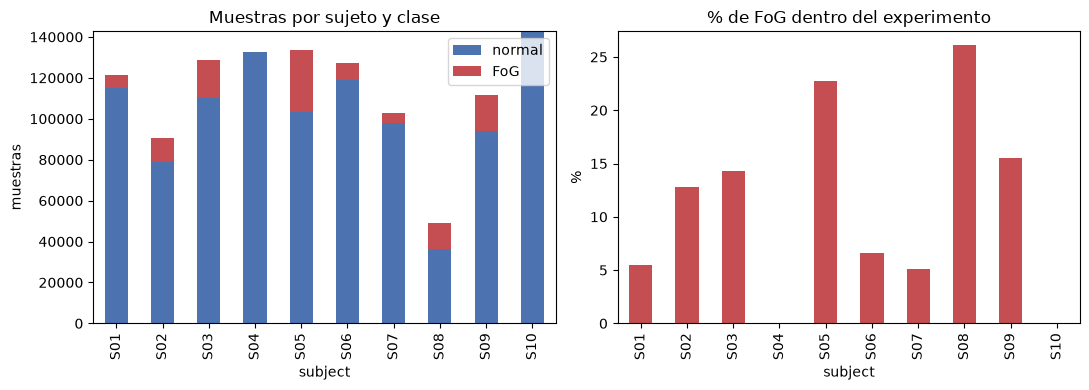

In [48]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

by_subj[["normal", "FoG"]].plot(
    kind="bar", stacked=True, ax=ax[0], color=["#4C72B0", "#C44E52"]
)
ax[0].set_title("Muestras por sujeto y clase")
ax[0].set_ylabel("muestras")

by_subj["%FoG"].plot(kind="bar", ax=ax[1], color="#C44E52")
ax[1].set_title("% de FoG dentro del experimento")
ax[1].set_ylabel("%")

plt.tight_layout()
plt.show()

## 2. Preparación de los datos

Esta sección transforma la señal cruda a los features que consumirá el modelo.


### 2.1. Preprocesamiento

Se descartan las muestras fuera del experimento (etiqueta `0` ), se aplica un filtro Butterworth pasa-bajas de 20 Hz (4º orden, fase cero) sobre los 9 ejes, que es el rango útil del movimiento de marcha, y se identifican los segmentos contiguos del experimento. Al descartar las muestras con etiqueta `0` la grabación queda partida en huecos, tal que cada tramo contiguo se trata como una secuencia independiente y la ventana posterior nunca cruza esos huecos.

La celda siguiente define las funciones que realizan este proceso.


In [49]:
def butter_lp(sig, fs=FS, fc=20, orden=4):
    """
    Filtro Butterworth pasa-bajas filtfilt, sin desfase sobre cada eje.
    fc=20 Hz recorta el ruido por encima del rango útil del movimiento de la marcha.
    """
    b, a = butter(orden, fc / (fs / 2), btype="low")
    return filtfilt(b, a, sig, axis=0)


def contiguous_segments(ann):
    idx = np.where(ann != 0)[0]
    if len(idx) == 0:
        return []
    splits = np.where(np.diff(idx) > 1)[0] + 1
    return np.split(idx, splits)


def build_preprocesado(files_by_subject, fs=FS, path=PREPROCESSED_PATH):
    if path.exists():
        return pickle.load(open(path, "rb"))
    segs = []
    for s, recs in files_by_subject.items():
        for p in recs:
            df = load_recording(p)
            acc = butter_lp(df[AXES].values, fs=fs)
            ann = df[LABEL].values.astype(int)
            for k, seg in enumerate(contiguous_segments(ann)):
                segs.append(
                    {
                        "subject": s,
                        "rec": p.name,
                        "seg_id": k,
                        "acc": acc[seg],
                        "ann": ann[seg],
                    }
                )
    pickle.dump(segs, open(path, "wb"))
    return segs

In [50]:
segmentos = build_preprocesado(files_by_subject)
print(
    "Segmentos contiguos:",
    len(segmentos),
    "| muestras totales:",
    sum(len(x["ann"]) for x in segmentos),
)

Segmentos contiguos: 35 | muestras totales: 1140835


### 2.2 Ventaneo

La señal se divide en ventanas de 3 segundos (192 muestras a 64 Hz) con un paso de 1.5 segundos, (solape 50%). La duración de 3 segundos da una resolución en frecuencia suficiente para separar la banda locomotora (0.5 a 3 Hz) de la banda de freezing (3 a 8 Hz), el solapamiento del 50% es el balance habitual entre resolución temporal y cantidad de ventanas. El ventaneo se aplica dentro de cada segmento contiguo, de modo que ninguna ventana mezcla tramos separados por huecos ni cruza la frontera entre sujetos.


In [51]:
WIN = 192  # ventana de 3s a 64 Hz
STEP = 96  # paso de 1.5s (50% solape)

### 2.3. Extracción de features

Por cada ventana y por sensor, se calcula la magnitud `‖(x,y,z)‖` de la aceleración como la norma de sus tres ejes, que es robusta a la orientación del sensor, se le quita la media, se aplica ventana de Hann y se obtiene su periodograma.

Se integran las bandas para el *Freeze Index* (potencia de la banda de freezing / la de la banda locomotora), `FI = pot[3 a 8 Hz] / pot[0.5 a 3 Hz]` . El Power Index es la potencia total de ambas bandas, `PI = pot[0.5 a 8 Hz]` , y se utiliza para distinguir un freeze de un reposo, dado que el FI por sí solo se vuelve inestable cuando casi no hay movimiento.


In [52]:
FEATS = ["FI_ankle", "PI_ankle", "FI_thigh", "PI_thigh", "FI_trunk", "PI_trunk"]
DEP_FEAT = "FI_ankle"  # feature de la dependencia inter-slice

In [53]:
def band_power(x, lo, hi, fs=FS):
    f, pxx = periodogram(x, fs=fs, window="hann", detrend="constant")
    return pxx[(f >= lo) & (f < hi)].sum()


def window_features(seg_acc, fs=FS):
    """
    Por sensor:
        magnitud ||(x,y,z)||
        FI (banda freeze / banda locomotora)
        PI (potencia total de ambas)
    """
    feats = {}
    for s, axes in SENSORS.items():
        cols = [AXES.index(e) for e in axes]
        m = np.sqrt((seg_acc[:, cols] ** 2).sum(axis=1))
        p_loco = band_power(m, 0.5, 3.0, fs=fs)
        p_freeze = band_power(m, 3.0, 8.0, fs=fs)
        feats[f"FI_{ s}"] = p_freeze / (p_loco + 1e-10)
        feats[f"PI_{ s}"] = p_loco + p_freeze
    return feats


def build_features(segmentos, win=WIN, step=STEP, fs=FS, path=FEATURES_PATH):
    """Ventanea cada segmento contiguo y calcula FI/PI por sensor en cada ventana."""
    if path.exists():
        return pickle.load(open(path, "rb"))
    rows = []
    for seg in segmentos:
        acc, ann = seg["acc"], seg["ann"]
        n_win = (len(ann) - win) // step + 1
        for w in range(n_win):
            i0, i1 = w * step, w * step + win
            feats = window_features(acc[i0:i1], fs=fs)
            base = int(
                np.bincount(ann[i0:i1]).argmax()
            )  # 1 normal, 2 freeze (voto mayoritario)
            rows.append(
                {
                    "subject": seg["subject"],
                    "rec": seg["rec"],
                    "seg_id": seg["seg_id"],
                    "w": w,
                    "start": i0 / fs,
                    "center": (i0 + win / 2) / fs,
                    "base": base,
                    **feats,
                }
            )
    df = pd.DataFrame(rows)
    pickle.dump(df, open(path, "wb"))
    return df

Validamos sobre una ventana, mostrando su espectro y las dos bandas.


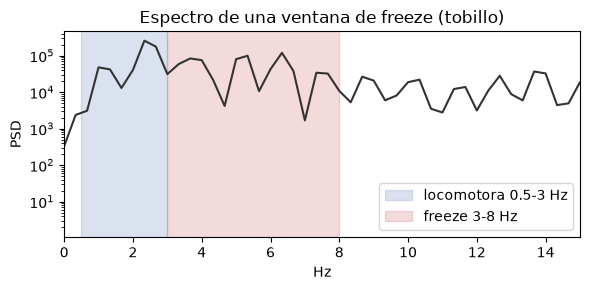

FI/PI de la ventana: {'FI_ankle': np.float64(1.262), 'PI_ankle': np.float64(1316043.888), 'FI_thigh': np.float64(0.857), 'PI_thigh': np.float64(163807.301), 'FI_trunk': np.float64(8.41), 'PI_trunk': np.float64(139476.78)}


In [54]:
ej = next(x for x in segmentos if (x["ann"] == 2).any())
i0 = min(np.where(ej["ann"] == 2)[0][0], len(ej["ann"]) - WIN)
cols_ankle = [AXES.index(e) for e in SENSORS["ankle"]]
m = np.sqrt((ej["acc"][i0 : i0 + WIN, cols_ankle] ** 2).sum(axis=1))
f, pxx = periodogram(m - m.mean(), fs=FS, window="hann", detrend="constant")

plt.figure(figsize=(6, 3))
plt.semilogy(f, pxx, color="#333")
plt.axvspan(0.5, 3, alpha=0.2, color="#4C72B0", label="locomotora 0.5-3 Hz")
plt.axvspan(3, 8, alpha=0.2, color="#C44E52", label="freeze 3-8 Hz")
plt.xlim(0, 15)
plt.xlabel("Hz")
plt.ylabel("PSD")
plt.legend()

plt.title("Espectro de una ventana de freeze (tobillo)")
plt.tight_layout()
plt.show()

print(
    "FI/PI de la ventana:",
    {k: round(v, 3) for k, v in window_features(ej["acc"][i0 : i0 + WIN]).items()},
)

In [55]:
feat_df = build_features(segmentos)

print("Ventanas:", len(feat_df))
display(feat_df[FEATS].describe().round(2))

Ventanas: 11838


,FI_ankle,PI_ankle,FI_thigh,PI_thigh,FI_trunk,PI_trunk
count,11838.00,1.183800e+04,11838.00,1.183800e+04,11838.00,11838.00
mean,2.98,5.264802e+05,2.87,1.426055e+05,4.53,30947.98
std,7.71,4.281473e+06,7.95,3.185177e+06,12.65,215511.58
min,0.00,0.000000e+00,0.00,0.000000e+00,0.00,0.00
25%,0.56,7.639000e+01,0.59,5.266000e+01,1.14,63.17
50%,1.56,2.813237e+04,1.42,4.790140e+03,2.22,6108.14
75%,3.17,5.179863e+05,2.91,8.414394e+04,4.33,36209.82
max,423.01,1.756721e+08,371.08,2.433447e+08,691.46,22665482.49


Se muestran las distribuciones de FI y PI por clase base, para ver si los features separan normal de freeze.


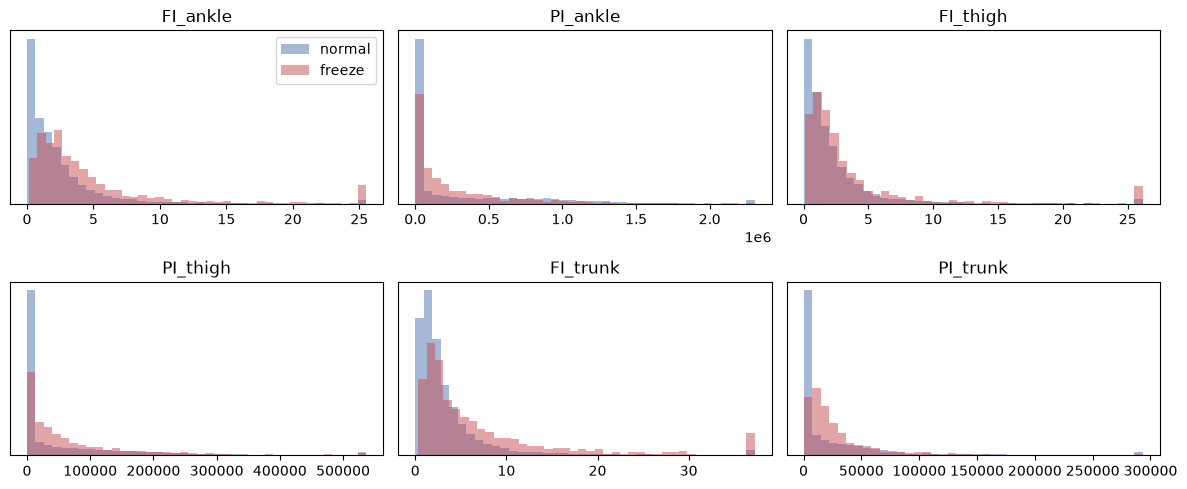

In [56]:
fig, ax = plt.subplots(2, 3, figsize=(12, 5))

for j, fcol in enumerate(FEATS):
    a = ax[j // 3, j % 3]
    for cl, col, lab in [(1, "#4C72B0", "normal"), (2, "#C44E52", "freeze")]:
        v = feat_df[feat_df.base == cl][fcol].clip(upper=feat_df[fcol].quantile(0.99))
        a.hist(v, bins=40, alpha=0.5, density=True, color=col, label=lab)

    a.set_title(fcol)
    a.set_yticks([])

ax[0, 0].legend()
plt.tight_layout()
plt.show()

### 2.4 Etiquetado

Se comparan dos esquemas de etiquetado. 

* **3 clases**,  `{normal, pre-FoG, FoG}`, donde el estado pre-FoG se construye con una regla pre-onset que marca como pre-FoG las ventanas normales cuyo centro cae en el intervalo `[onset - τ, onset)`. Los valores de τ provienen de la literatura donde se han evaluado valores entre 2 y 5 segundos. En esta práctica, comparamos `TAU_VALUES = [2, 3, 5]`. 
* **2 clases**,  `{normal, FoG}`, con las etiquetas originales, sin pre-FoG. Sirve para medir si el tercer estado aporta o no al modelo.


In [70]:
NORMAL, PREFOG, FOG = 0, 1, 2
GROUP = ["subject", "rec", "seg_id"]
TAU_VALUES = [2, 3, 5]  # ventanas pre-FoG (s) a comparar

In [86]:
def label_3class(df, tau):
    """
    3 clases. Mapea normal/freeze desde la anotación base y construye pre-FoG con regla pre-onset.
    """
    df = df.copy()
    df["state"] = df["base"].map({1: NORMAL, 2: FOG})
    for _, g in df.groupby(GROUP, sort=False):
        idx, base, start, center = (
            g.index.values,
            g.base.values,
            g.start.values,
            g.center.values,
        )
        for i in range(1, len(idx)):
            if base[i] == ANN_FREEZE and base[i - 1] != ANN_FREEZE:  # onset normal -> freeze
                onset = start[i]
                for j in range(i):
                    if base[j] == 1 and onset - tau <= center[j] < onset:
                        df.at[idx[j], "state"] = PREFOG
    return df


def label_2class(df):
    """Esquema de 2 clases: etiquetas originales sin pre-FoG (0 normal, 1 FoG)."""
    df = df.copy()
    df["state"] = (df["base"] == FOG).astype(int)
    return df

In [87]:
for tau in TAU_VALUES:
    n = (label_3class(feat_df, tau).state == PREFOG).sum()
    print(f"tau={tau}s -> ventanas pre-FoG: {n}")

tau=2s -> ventanas pre-FoG: 193
tau=3s -> ventanas pre-FoG: 363
tau=5s -> ventanas pre-FoG: 524
